# Quantum Physics-Informed Neural Networks for PDEs — a guided walkthrough

Reproduction of **Panichi, Corli, Prati, *Quantum physics informed neural networks for multi-variable partial differential equations*** ([arXiv:2503.12244](https://arxiv.org/abs/2503.12244)).

The paper trains a *continuous-variable* (CV) photonic quantum neural network as a
Physics-Informed Neural Network (PINN) and solves two textbook PDEs with it: the 1D
Poisson equation and the 1D heat equation. Its methodological contribution is a
**consistency loss** that removes the need for nested automatic differentiation
through the quantum simulator.

This notebook is meant to be read top to bottom. Each section introduces one idea,
checks it with a small computation, and then shows the result of the full training
runs kept under `results/`.

| Section | What you will see | Runs live? |
|---|---|---|
| 1. The two PDEs | The problems, their reference solutions, what{a} PINN minimises | yes (instant) |
| 2. CV quantum neural networks | Qumodes, Fock truncation, the five gates, one Killoran layer | yes (instant) |
| 3. The QPINN | Input encoding, layer stack, homodyne read-out, parameter count | yes (instant) |
| 4. The consistency-loss trick | Why nested autograd hurts and how two outputs avoid it | yes (seconds) |
| 5. Poisson, live | Train the smoke configuration in the notebook | yes (~1 min) |
| 6. Poisson, full runs | QPINN vs classical PINN vs MerLin from `results/runs/` | loaded |
| 7. Ablation | Nested autograd vs consistency loss, head to head | loaded |
| 8. Heat equation | Live smoke run, curated runs, 5-seed sweep vs the paper | yes (~3 min) |
| 9. MerLin adaptation | The linear-optics version of the same training scheme | yes (~30 s) |
| 10. Conclusions | What reproduced, what did not, what to run next | — |

**How to run it.** From the paper directory (`papers/CV_QPINN_PDE`) with the
requirements installed:

```bash
pip install -r requirements.txt
jupyter notebook notebook.ipynb
```

Every plot from a long run is rebuilt from the compact records in `results/runs/`, so
no raw `outdir/` is needed. The live cells use the *smoke* hyper-parameters (small Fock
cutoff, few epochs) and finish in a few minutes on a laptop CPU; the paper-accurate
configurations take hours and are described at the end.

In [1]:
import inspect
import json
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

# The library lives in ./lib and needs the repository root for the shared runtime.
PAPER_DIR = Path.cwd().resolve()
if not (PAPER_DIR / "lib").is_dir():
    raise RuntimeError("Run this notebook from papers/CV_QPINN_PDE")
REPO_ROOT = PAPER_DIR.parents[1]
for p in (PAPER_DIR, REPO_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from lib.cv_simulator import CVOperators, displacement, vacuum_state
from lib.data import HeatProblem, PoissonProblem, regular_grid_2d, sobol_1d
from lib.losses import heat_total_loss, poisson_nested_loss, poisson_total_loss
from lib.metrics import summarise
from lib.pinn_baseline import FCNN, hidden_layers_for_param_count
from lib.qpinn_model import QPINN, QPINNConfig
from lib.training import train_heat, train_poisson

torch.set_default_dtype(torch.float64)
DEVICE = torch.device("cpu")
CDTYPE = torch.complex128

# One colour per *model family*, used consistently in every figure.
C = {
    "qpinn": "#2a78d6",   # CV-QPINN, consistency loss (the paper's scheme)
    "nested": "#4a3aa7",  # CV-QPINN, nested autograd (ablation)
    "pinn": "#eb6834",    # classical fully-connected PINN
    "merlin": "#1baf7a",  # MerLin linear-optics adaptation
    "ref": "#0b0b0b",     # analytic / RK45 reference
    "paper": "#52514e",   # values quoted from the paper
}
BLUES = ["#9ec5f4", "#5598e7", "#256abf", "#0d366b"]  # ordinal ramp (light -> dark)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "lines.linewidth": 1.6,
    "legend.frameon": False,
    "font.size": 9.5,
})

RESULTS = PAPER_DIR / "results"


def load_run(label: str) -> dict:
    # Curated run record: metrics + loss history + predictions.
    return json.loads((RESULTS / "runs" / f"{label}.json").read_text())


def history_arrays(run: dict) -> dict[str, np.ndarray]:
    # Turn the list-of-dicts loss history into one array per loss term.
    hist = run["history"]
    keys = sorted({k for h in hist for k in h if k not in ("phase",)})
    return {k: np.array([h.get(k, np.nan) for h in hist], dtype=float) for k in keys}


def md_table(header: list[str], rows: list[list]) -> None:
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    lines += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(lines)))


def fmt(x: float) -> str:
    return f"{x:.2e}"


print("torch", torch.__version__, "| paper dir:", PAPER_DIR.name)

torch 2.10.0+cu128 | paper dir: CV_QPINN_PDE


## 1. The two PDEs and what{a} PINN minimises

A Physics-Informed Neural Network represents the unknown solution by a trainable
function $u_\theta(x)$ and, instead of fitting data, minimises the *residual of the
differential equation* at a set of **collocation points** plus penalties for the
boundary (and initial) conditions. The derivatives of $u_\theta$ that{a}ppear in the
residual are obtained by automatic differentiation. No labelled solution is ever used
during training; the reference solutions below are only used to *score* the result.

### 1D Poisson equation (paper §IV.A)

$$u''(x) + \sin(4x) = 0,\qquad x\in[0,\tfrac{\pi}{2}],\qquad u(0)=u(\tfrac{\pi}{2})=0 .$$

Integrating twice and applying the boundary conditions gives the closed form
$u(x)=\sin(4x)/16$. The PINN loss for this problem is

$$\mathcal{L} = \lambda_{\mathrm{pde}}\,\big\langle (u_\theta'' + \sin 4x)^2 \big\rangle_{\text{coll}}
 + \lambda_{\mathrm{bc}}\,\big(u_\theta(0)^2 + u_\theta(\tfrac{\pi}{2})^2\big) + \dots$$

### 1D heat equation (paper §IV.B)

$$\partial_t T = \alpha\,\partial_x^2 T,\qquad x\in[-\tfrac{\pi}{2},\tfrac{\pi}{2}],\ t\in[0,0.5],\ \alpha=0.30,$$

with a Gaussian initial temperature $T(x,0)=\tfrac12\exp\!\big(-(x-\mu)^2/2\sigma^2\big)$
($\mu=-\pi/8$, $\sigma^2=0.2$) and $T=0$ at both ends. There is no closed form on a
finite interval with these boundary conditions, so the reference is computed with a
finite-difference discretisation in $x$ integrated by SciPy's RK45 in $t$
(`lib/data.py::HeatProblem.reference_solution`).

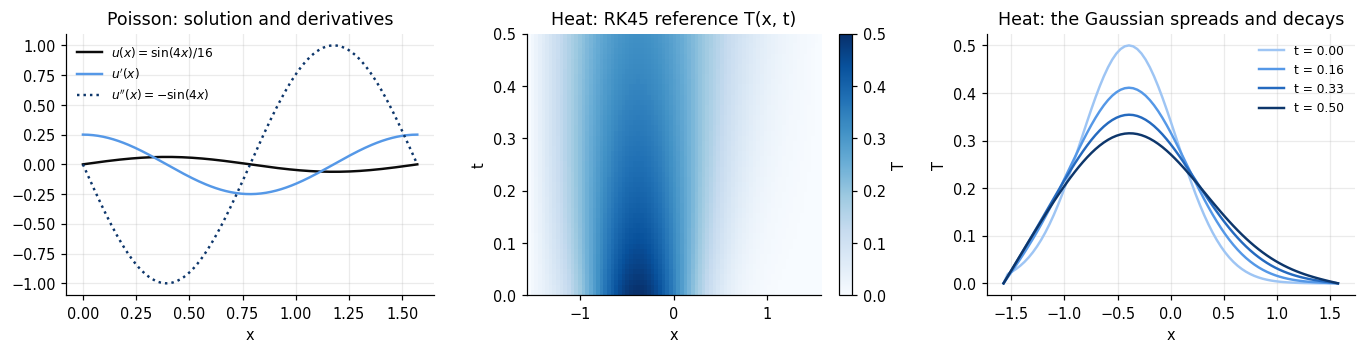

In [2]:
poisson = PoissonProblem()
heat = HeatProblem()

x = torch.linspace(poisson.x_min, poisson.x_max, 200)
ref = heat.reference_solution(nx=81, nt=51)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.3))

ax = axes[0]
ax.plot(x, poisson.analytic(x), color=C["ref"], label=r"$u(x)=\sin(4x)/16$")
ax.plot(x, poisson.analytic_grad(x), color=BLUES[1], label=r"$u'(x)$")
ax.plot(x, -poisson.forcing(x), color=BLUES[3], ls=":", label=r"$u''(x)=-\sin(4x)$")
ax.set(xlabel="x", title="Poisson: solution and derivatives")
ax.legend(fontsize=8)

ax = axes[1]
im = ax.imshow(
    ref["T"], origin="lower", aspect="auto", cmap="Blues", vmin=0, vmax=0.5,
    extent=(heat.x_min, heat.x_max, heat.t_min, heat.t_max),
)
ax.grid(False)
ax.set(xlabel="x", ylabel="t", title="Heat: RK45 reference T(x, t)")
fig.colorbar(im, ax=ax, label="T")

ax = axes[2]
for i, k in enumerate(np.linspace(0, len(ref["t"]) - 1, 4).astype(int)):
    ax.plot(ref["x"], ref["T"][k], color=BLUES[i], label=f"t = {ref['t'][k]:.2f}")
ax.set(xlabel="x", ylabel="T", title="Heat: the Gaussian spreads and decays")
ax.legend(fontsize=8)
fig.tight_layout()

Two things to keep in mind for later:

* The Poisson solution has amplitude $1/16 \approx 0.06$. An RMSE of $10^{-3}$ therefore
  already corresponds to a $\sim 2\%$ relative error; the paper's reported RMSE is
  $1.09\times10^{-4}$.
* The heat problem is *two-variable*: the network must take both $x$ and $t$ as inputs.
  In the QPINN this is done by encoding each variable on its own qumode.

## 2. Continuous-variable quantum neural networks in five minutes

The paper's network is the CV quantum neural network of Killoran *et al.*
(Phys. Rev. Research 1, 033063). The carrier of information is a **qumode**: one mode
of the electromagnetic field, whose state lives in an infinite-dimensional Hilbert space
spanned by photon-number (Fock) states $|0\rangle, |1\rangle, |2\rangle,\dots$. To
simulate it on a classical computer the space is **truncated** to the first $d$ Fock
states; $d$ is called the *cutoff*.

The building blocks are five gates, each a unitary generated by a polynomial in the
ladder operators $\hat{a},\hat{a}^\dagger$:

| Gate | Definition | Role in the "layer as a neural network" analogy |
|---|---|---|
| Rotation $R(\phi)=e^{-i\phi\hat{n}}$ | phase shift | orthogonal (unitary) mixing |
| Beam splitter $BS(\theta,\phi)$ | two-mode linear mixing | orthogonal mixing across modes |
| Squeezing $S(r)=e^{\frac r2(\hat{a}^2-\hat{a}^{\dagger 2})}$ | rescales the quadratures | the singular values of a weight matrix |
| Displacement $D(\alpha)=e^{\alpha(\hat{a}^\dagger-\hat{a})}$ | shifts the state in phase space | the bias term |
| Kerr $K(\kappa)=e^{i\kappa\hat{n}^2}$ | photon-number dependent phase | the **non-linearity** |

A **Killoran layer** is $\mathcal L = K\circ D\circ U_2\circ S\circ U_1$, where
$U_{1,2}$ are interferometers (beam splitters + rotations). Rotations and interferometers
are *passive* (they conserve photon number); squeezing, displacement and Kerr are
*active*. Every gate is differentiable with respect to its parameter, so a stack of
layers is a trainable non-linear map.

**How this reproduction simulates it.** The paper uses Strawberry Fields with its
TensorFlow backend. Here every gate is written as a $d\times d$ (or $d^2\times d^2$)
matrix in the truncated Fock basis and exponentiated with `torch.matrix_exp`, so
PyTorch's autograd handles the gradients (`lib/cv_simulator.py`). One consequence
worth knowing: `matrix_exp` of a truncated anti-Hermitian generator is *exactly*
unitary, so the simulated state keeps unit norm to machine precision. In Strawberry
Fields the truncated gates leak norm, which is why the paper adds a *trace loss*
$(\langle\psi|\psi\rangle-1)^2$; we keep that term for parity but it will be
numerically zero in every history below.

### 2.1 Sanity check: how good is the truncation?

The read-out of the network is a homodyne measurement of the position quadrature
$\hat{X}=(\hat{a}+\hat{a}^\dagger)/\sqrt{2}$. For a coherent state $D(\alpha)|0\rangle$ the
exact answer is $\langle\hat{X}\rangle=\sqrt{2}\,\alpha$, and its photon-number distribution
is Poisson with mean $\alpha^2$. The Poisson input domain reaches $x=\pi/2\approx1.57$,
which is directly used as the displacement amplitude, so it matters how many Fock
levels are needed for that{a}mplitude.

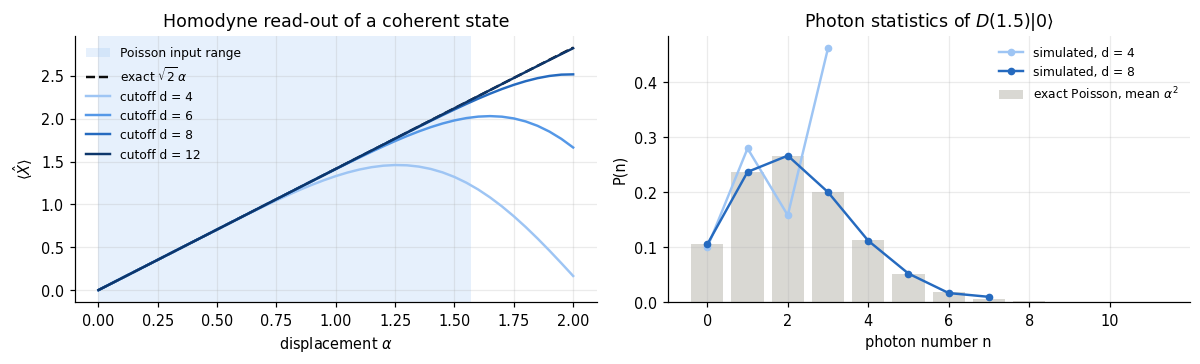

In [3]:
alphas = torch.linspace(0.0, 2.0, 41)
cutoffs = (4, 6, 8, 12)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

ax = axes[0]
ax.axvspan(0, math.pi / 2, color=BLUES[0], alpha=0.25, lw=0, label="Poisson input range")
ax.plot(alphas, math.sqrt(2) * alphas, color=C["ref"], ls="--", label=r"exact $\sqrt{2}\,\alpha$")
for d, col in zip(cutoffs, BLUES):
    ops = CVOperators(d=d, dtype=CDTYPE, device=DEVICE)
    vac = vacuum_state(1, d, CDTYPE, DEVICE)
    states = torch.einsum("bij,j->bi", displacement(alphas, ops), vac)
    x_obs = torch.einsum("bi,ij,bj->b", states.conj(), ops.x, states).real
    ax.plot(alphas, x_obs, color=col, label=f"cutoff d = {d}")
ax.set(xlabel=r"displacement $\alpha$", ylabel=r"$\langle \hat{X}\rangle$",
       title="Homodyne read-out of a coherent state")
ax.legend(fontsize=8)

ax = axes[1]
alpha0 = 1.5
n = np.arange(12)
ax.bar(n, np.exp(-alpha0**2) * alpha0 ** (2 * n) / [math.factorial(k) for k in n],
       color="#d9d8d3", width=0.8, label=r"exact Poisson, mean $\alpha^2$")
for d, col in zip((4, 8), (BLUES[0], BLUES[2])):
    ops = CVOperators(d=d, dtype=CDTYPE, device=DEVICE)
    vac = vacuum_state(1, d, CDTYPE, DEVICE)
    probs = (displacement(torch.tensor(alpha0), ops) @ vac).abs() ** 2
    ax.plot(np.arange(d), probs, "o-", color=col, ms=4, label=f"simulated, d = {d}")
ax.set(xlabel="photon number n", ylabel="P(n)", title=rf"Photon statistics of $D({alpha0})|0\rangle$")
ax.legend(fontsize=8)
fig.tight_layout()

*Reading the figure.* With cutoff 4 the simulated read-out bends away from the exact
line well inside the input range: the state is being pushed against the truncation wall.
From cutoff 8 upwards the coherent state is represented faithfully up to
$\alpha\approx1.6$, and the photon statistics (right) match the Poisson law. This is why
the smoke configurations use cutoff 8 (Poisson) and 10 (heat), and why the paper goes
to 10 and 20. A larger cutoff is more accurate but every gate is a $d\times d$
matrix exponential and the two-mode state has $d^2$ amplitudes, so the cost grows fast.

### 2.2 One Killoran layer is a non-linear function of its input

Take the input state $D(x)|0\rangle$, push it through one multi-qumode layer and one
single-qumode layer with random parameters, and read $\langle\hat{X}_0\rangle$. Without any
gate the read-out would be the straight line $\sqrt{2}\,x$; the layers turn it into a smooth
non-linear function, different for every draw of the parameters. That family of functions
is what training will search through. (The initialisation widths are exaggerated here
to make the non-linearity visible; the paper initialises the active gates close to zero,
so a fresh QPINN starts very near the straight line.)

largest |<psi|psi> - 1| over all inputs and seeds: 9.3e-15  (unitarity holds)


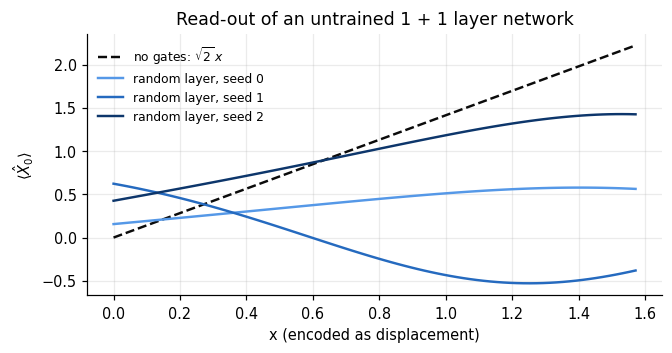

In [4]:
x_demo = torch.linspace(0, math.pi / 2, 80)
fig, ax = plt.subplots(figsize=(6.2, 3.3))
ax.plot(x_demo, math.sqrt(2) * x_demo, color=C["ref"], ls="--", label=r"no gates: $\sqrt{2}\,x$")
worst_norm_error = 0.0
for i, seed in enumerate((0, 1, 2)):
    cfg = QPINNConfig(n_qumodes=2, n_multi_layers=1, n_single_layers=1, cutoff=8,
                      active_sd=0.3, passive_sd=0.8, seed=seed)
    demo = QPINN(cfg)
    with torch.no_grad():
        u, ux, trace = demo(x_demo)
    worst_norm_error = max(worst_norm_error, float((trace - 1).abs().max()))
    ax.plot(x_demo, u, color=BLUES[i + 1], label=f"random layer, seed {seed}")
ax.set(xlabel="x (encoded as displacement)", ylabel=r"$\langle \hat{X}_0\rangle$",
       title="Read-out of an untrained 1 + 1 layer network")
ax.legend(fontsize=8)
fig.tight_layout()
print(f"largest |<psi|psi> - 1| over all inputs and seeds: {worst_norm_error:.1e}  (unitarity holds)")

## 3. The QPINN: from an input $x$ to the pair $(u, u_x)$

The network used in the paper (`lib/qpinn_model.py`) has two qumodes and works in
three steps:

1. **Encoding.** The input is written into the state by displacement:
   $|\psi_{\rm in}\rangle = D(x)|0\rangle\otimes|0\rangle$ for Poisson, and
   $D(x)|0\rangle\otimes D(t)|0\rangle$ for the heat equation. No classical
   pre-processing, no re-uploading.
2. **Layers.** First $N_m$ *multi-qumode* layers, whose interferometers mix the two
   modes with beam splitters, then $N_s$ *single-qumode* layers that{a}ct on each mode
   separately. The paper uses $4+4$ for Poisson and $2+2$ for heat; the smoke
   configurations use $2+2$ for both.
3. **Read-out.** One homodyne expectation per qumode:
   $u = \langle\hat{X}_0\rangle$ and $\hat{u}_x = \langle\hat{X}_1\rangle$.
   The second output is the paper's key design choice and is explained in the next
   section. The norm $\langle\psi|\psi\rangle$ is returned as a third value for the
   trace loss.

Parameter count: a multi-qumode layer has two interferometers (beam splitter angle and
phase plus two rotations each), two squeezers, two displacements and two Kerr gates,
i.e. $2\times4 + 3\times2 = 14$ parameters; a single-qumode layer has five gates per
mode, i.e. $10$. The $2+2$ smoke network therefore has $2\cdot14 + 2\cdot10 = 48$
trainable parameters.

multi-qumode layers : 2 x 14 params
single-qumode layers: 2 x 10 params
total trainable     : 48
state tensor per input: 8 x 8 complex amplitudes


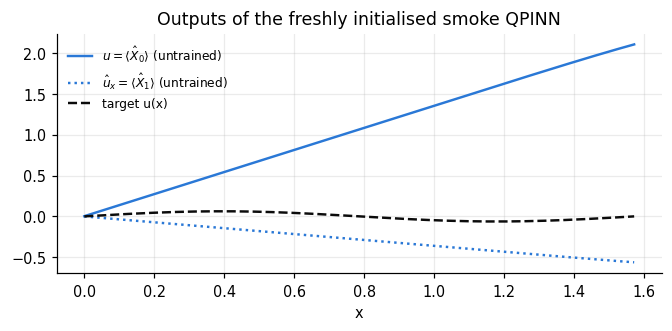

In [5]:
smoke_cfg = QPINNConfig(n_qumodes=2, n_multi_layers=2, n_single_layers=2, cutoff=8, seed=42)
model = QPINN(smoke_cfg)
n_multi = sum(p.numel() for p in model.multi_layers.parameters())
n_single = sum(p.numel() for p in model.single_layers.parameters())
print(f"multi-qumode layers : {smoke_cfg.n_multi_layers} x {n_multi // smoke_cfg.n_multi_layers} params")
print(f"single-qumode layers: {smoke_cfg.n_single_layers} x {n_single // smoke_cfg.n_single_layers} params")
print(f"total trainable     : {model.n_trainable()}")
print(f"state tensor per input: {smoke_cfg.cutoff} x {smoke_cfg.cutoff} complex amplitudes")

x_eval = torch.linspace(poisson.x_min, poisson.x_max, 200)
with torch.no_grad():
    u0, ux0, tr0 = model(x_eval)
fig, ax = plt.subplots(figsize=(6.2, 3.1))
ax.plot(x_eval, u0, color=C["qpinn"], label=r"$u=\langle \hat{X}_0\rangle$ (untrained)")
ax.plot(x_eval, ux0, color=C["qpinn"], ls=":", label=r"$\hat{u}_x=\langle \hat{X}_1\rangle$ (untrained)")
ax.plot(x_eval, poisson.analytic(x_eval), color=C["ref"], ls="--", label="target u(x)")
ax.set(xlabel="x", title="Outputs of the freshly initialised smoke QPINN")
ax.legend(fontsize=8)
fig.tight_layout()

At initialisation the first output is essentially $\sqrt{2}\,x$ (the encoding passes
straight through) and the second output is close to zero because mode 1 starts in the
vacuum. Training has to bend the first output onto a sine of amplitude $1/16$ and, at
the same time, turn the second output into its derivative.

## 4. The consistency-loss trick

A PINN for a second-order PDE needs $u_\theta''$. The standard recipe is *nested*
automatic differentiation: differentiate the network output once, then differentiate
the result again. For a classical network this is cheap. For the CV simulator each
differentiation pass has to back-propagate through every `matrix_exp` and every
$d^2$-dimensional state, and the paper reports (§III.B) that the memory of the nested
graph grows super-linearly with the cutoff until the run no longer fits.

The paper's answer is architectural. Give the network **one extra output per derivative
order** and tie the outputs together with a loss:

$$
\mathcal L_{\rm cons} = \Big\langle \big(\partial_x u_\theta - \hat{u}_{x,\theta}\big)^2 \Big\rangle_{\rm coll},
\qquad
\mathcal L_{\rm pde} = \Big\langle \big(\partial_x \hat{u}_{x,\theta} + \sin 4x\big)^2 \Big\rangle_{\rm coll}.
$$

Both terms need only a **single** autograd pass through the network. If the consistency
term is driven to zero, $\hat{u}_x = u'$ and the residual is the true second derivative.
The full Poisson loss is

$$
\mathcal L = \lambda_{\rm pde}\mathcal L_{\rm pde} + \lambda_{\rm bc}\mathcal L_{\rm bc}
 + \lambda_{\rm cons}\mathcal L_{\rm cons} + \lambda_{\rm tr}\big\langle(\langle\psi|\psi\rangle-1)^2\big\rangle ,
$$

with all four weights equal to $0.25$ in the Poisson experiments. For the heat equation
the same idea gives $\partial_t u$ and $\partial_x \hat{u}_x$ from one pass each, plus an
initial-condition term with weight $0.6$.

Here is the exact implementation used by every Poisson run in this reproduction:

In [6]:
print(inspect.getsource(poisson_total_loss))

def poisson_total_loss(
    model,
    x_collocation: torch.Tensor,
    x_bc_left: torch.Tensor,
    x_bc_right: torch.Tensor,
    lambdas: dict[str, float],
) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
    """1D Poisson: u'' + sin(4x) = 0, u(0)=u(pi/2)=0.

    The "physics" residual uses the chain ux -> d(ux)/dx (one autograd hop,
    no nested gradients) instead of d^2 u / dx^2 directly.
    """
    x_collocation = x_collocation.detach().clone().requires_grad_(True)
    u, ux, trace = model(x_collocation)
    ux_x = torch.autograd.grad(ux.sum(), x_collocation, create_graph=True)[0]
    pde_residual = ux_x + torch.sin(4 * x_collocation)
    loss_pde = (pde_residual**2).mean()

    u_left, _, _ = model(x_bc_left)
    u_right, _, _ = model(x_bc_right)
    loss_bc = (u_left**2).mean() + (u_right**2).mean()

    u_x_auto = torch.autograd.grad(u.sum(), x_collocation, create_graph=True)[0]
    loss_consistency = ((u_x_auto - ux) ** 2).mean()

    loss_trace = ((trace - 1.0) ** 2).mean

The ablation used later replaces this with `poisson_nested_loss`, which computes
$u''$ by differentiating twice and ignores the second output entirely. Before training
anything, let us see what the two formulations cost per optimisation step on the
$2+2$ network at two cutoffs. Timings are single-machine and noisy, and at these small
cutoffs the two formulations cost roughly the same per step; the difference the paper
cares about is *memory*, which is measured in section 7.

In [7]:
x_coll = sobol_1d(64, poisson.x_min, poisson.x_max, seed=42)
x_bc = (torch.tensor([poisson.x_min]), torch.tensor([poisson.x_max]))
lambdas_poisson = {"pde": 0.25, "bc": 0.25, "consistency": 0.25, "trace": 0.25}
lambdas_nested = {"pde": 0.34, "bc": 0.33, "consistency": 0.0, "trace": 0.33}


def time_one_step(loss_fn, lambdas, cutoff, reps=3):
    probe = QPINN(QPINNConfig(n_qumodes=2, n_multi_layers=2, n_single_layers=2, cutoff=cutoff, seed=42))
    loss, parts = loss_fn(probe, x_coll, *x_bc, lambdas)  # warm-up, not timed
    t0 = time.perf_counter()
    for _ in range(reps):
        probe.zero_grad()
        loss, parts = loss_fn(probe, x_coll, *x_bc, lambdas)
        loss.backward()
    return (time.perf_counter() - t0) / reps, {k: float(v) for k, v in parts.items()}


rows = []
for cutoff in (8, 12):
    t_cons, parts_cons = time_one_step(poisson_total_loss, lambdas_poisson, cutoff)
    t_nest, parts_nest = time_one_step(poisson_nested_loss, lambdas_nested, cutoff)
    rows.append([cutoff, "consistency (paper)", "1 (u and $\\hat{u}_x$ share the graph)", f"{t_cons:.2f}", fmt(parts_cons["pde"])])
    rows.append([cutoff, "nested (ablation)", "2 (grad of grad)", f"{t_nest:.2f}", fmt(parts_nest["pde"])])
md_table(["Cutoff", "Loss", "Autograd passes through the network", "Time per step (s)", "Initial PDE residual"], rows)
print(f"initial consistency mismatch <(u' - ux)^2> = {parts_cons['consistency']:.3f}  "
      "(large: the two outputs know nothing about each other yet)")

| Cutoff | Loss | Autograd passes through the network | Time per step (s) | Initial PDE residual |
|---|---|---|---|---|
| 8 | consistency (paper) | 1 (u and $\hat{u}_x$ share the graph) | 0.13 | 6.25e-01 |
| 8 | nested (ablation) | 2 (grad of grad) | 0.14 | 6.62e-01 |
| 12 | consistency (paper) | 1 (u and $\hat{u}_x$ share the graph) | 0.31 | 6.31e-01 |
| 12 | nested (ablation) | 2 (grad of grad) | 0.42 | 5.00e-01 |

initial consistency mismatch <(u' - ux)^2> = 2.715  (large: the two outputs know nothing about each other yet)


## 5. Poisson, live: train the smoke configuration

We now train the $2+2$ layer, cutoff-8 QPINN with exactly the settings of
`configs/poisson_smoke.json`: 64 Sobol collocation points, Adam with learning rate
0.05, 200 epochs, seed 42. This is the same configuration as the curated run
`poisson_qpinn_smoke_200ep`, so the final RMSE can be compared with the stored value
(small differences between machines come from BLAS and `matrix_exp` rounding).

In [8]:
LIVE_EPOCHS_POISSON = 200  # raise to ~800 for a noticeably better fit (a few minutes)

torch.manual_seed(42)
qpinn_live = QPINN(smoke_cfg)
t0 = time.perf_counter()
out_live = train_poisson(
    qpinn_live, x_coll, x_bc, loss_fn=poisson_total_loss, lr=0.05,
    epochs=LIVE_EPOCHS_POISSON, lambdas=lambdas_poisson, log_every=50,
)
wall_live = time.perf_counter() - t0

with torch.no_grad():
    u_live, ux_live, _ = qpinn_live(x_eval)
u_ref = poisson.analytic(x_eval)
m_live = summarise(u_live, u_ref)
stored = load_run("poisson_qpinn_smoke_200ep")
print(f"\nlive run : RMSE {m_live['rmse']:.3e}  in {wall_live:.0f} s (best epoch {out_live['best']['epoch']})")
print(f"stored   : RMSE {stored['metrics']['rmse']:.3e}  in {stored['wall_time_sec']:.0f} s "
      f"(run {stored['source_run']})")

  [epoch     0] total=1.9308e+00 pde=6.2497e-01 bc=4.4401e+00 consist=2.6580e+00 trace=3.9795e-30


  [epoch    50] total=7.0816e-03 pde=7.7201e-03 bc=9.7775e-04 consist=1.9629e-02 trace=5.1736e-30


  [epoch   100] total=4.9607e-03 pde=1.5256e-03 bc=7.3518e-06 consist=1.8310e-02 trace=2.4851e-27


  [epoch   150] total=5.2367e-04 pde=6.1531e-04 bc=3.7760e-05 consist=1.4416e-03 trace=1.1364e-29


  [epoch   199] total=3.5738e-04 pde=1.3042e-04 bc=4.1504e-07 consist=1.2987e-03 trace=1.2584e-29

live run : RMSE 4.641e-03  in 24 s (best epoch 199)
stored   : RMSE 4.641e-03  in 168 s (run run_20260528-120233)


trace loss at the last epoch: 1.3e-29  (unitarity makes it vanish)


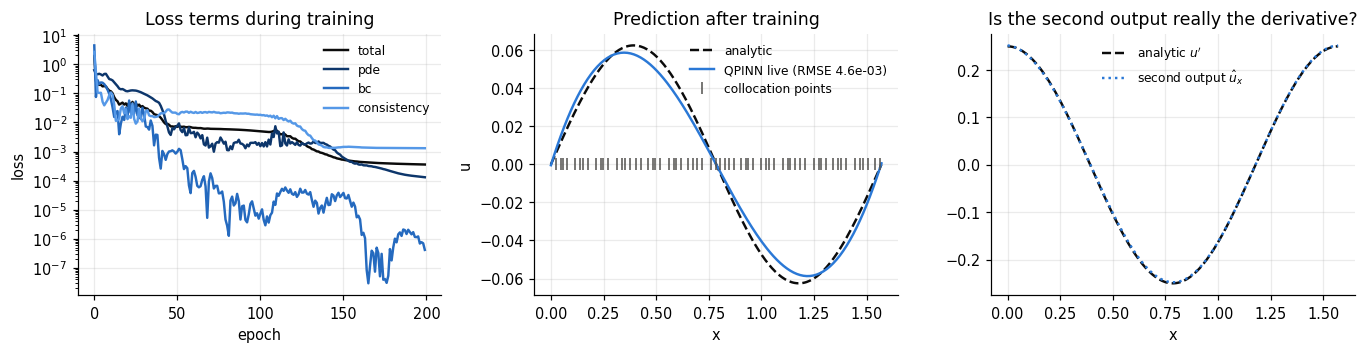

In [9]:
hist = {k: np.array([h[k] for h in out_live["history"]]) for k in ("pde", "bc", "consistency", "trace", "total")}
ep = np.arange(len(hist["total"]))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.3))
ax = axes[0]
for k, col in zip(("total", "pde", "bc", "consistency"), (C["ref"], BLUES[3], BLUES[2], BLUES[1])):
    ax.semilogy(ep, hist[k], color=col, label=k)
ax.set(xlabel="epoch", ylabel="loss", title="Loss terms during training")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(x_eval, u_ref, color=C["ref"], ls="--", label="analytic")
ax.plot(x_eval, u_live, color=C["qpinn"], label=f"QPINN live (RMSE {m_live['rmse']:.1e})")
ax.plot(x_coll, torch.zeros_like(x_coll), "|", color=C["paper"], ms=8, label="collocation points")
ax.set(xlabel="x", ylabel="u", title="Prediction after training")
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(x_eval, poisson.analytic_grad(x_eval), color=C["ref"], ls="--", label=r"analytic $u'$")
ax.plot(x_eval, ux_live, color=C["qpinn"], ls=":", label=r"second output $\hat{u}_x$")
ax.set(xlabel="x", title="Is the second output really the derivative?")
ax.legend(fontsize=8)
fig.tight_layout()
print(f"trace loss at the last epoch: {hist['trace'][-1]:.1e}  (unitarity makes it vanish)")

*Reading the curves.* The boundary term collapses first (two points are easy to pin),
then the PDE residual and the consistency term decrease together: the network cannot
lower the residual without also making its second output track $u'$. The trace term
stays at floating-point zero, as anticipated in section 2. After 200 epochs the fit is
visibly right but the RMSE of a few $10^{-3}$ is still about 40× above the paper's
$1.09\times10^{-4}$, which was obtained with twice the depth, cutoff 10 and 5000 epochs.

## 6. Poisson, full runs: QPINN vs classical PINN vs MerLin

The records in `results/runs/` hold the loss history and the final prediction of the
headline runs (promoted from the raw `outdir/` with
`python utils/curate_results.py <run> --label <label> --with-arrays`). Three
models were trained on the Poisson task with the consistency-loss scheme:

| Record | Model | Trainable params | Training |
|---|---|---:|---|
| `poisson_qpinn_smoke_200ep` | CV-QPINN, 2+2 layers, cutoff 8 | 48 | 200 epochs, lr 0.05, 64 points |
| `poisson_pinn_3000ep` | classical `tanh` network, one hidden layer of 22 | 90 | 3000 epochs, lr 0.005, 258 points |
| `poisson_merlin_600ep` | MerLin interferometer, 6 modes, 3 photons + 2 linear heads | 162 | 600 epochs, lr 0.02, 64 points |

The classical PINN is the *fair baseline* of this reproduction: it returns the same
$(u,\hat{u}_x)$ pair and is trained with the very same loss (section 4), so the only
difference is the function family. The MerLin network is described in section 9.

| Run | Model | Params | Epochs | RMSE | MAE | L∞ | Wall (s) |
|---|---|---|---|---|---|---|---|
| paper QPINN (4+4 layers, cutoff 10) | CV-QPINN | 88 | 5000 | 1.09e-04 | — | — | — |
| poisson_qpinn_smoke_200ep | CV-QPINN | 48 | 200 | 4.64e-03 | 4.11e-03 | 7.45e-03 | 168 |
| poisson_pinn_3000ep | classical PINN | 90 | 3000 | 8.28e-04 | 6.62e-04 | 1.68e-03 | 176 |
| poisson_merlin_600ep | MerLin PINN | 162 | 600 | 2.37e-04 | 2.04e-04 | 4.41e-04 | 133 |

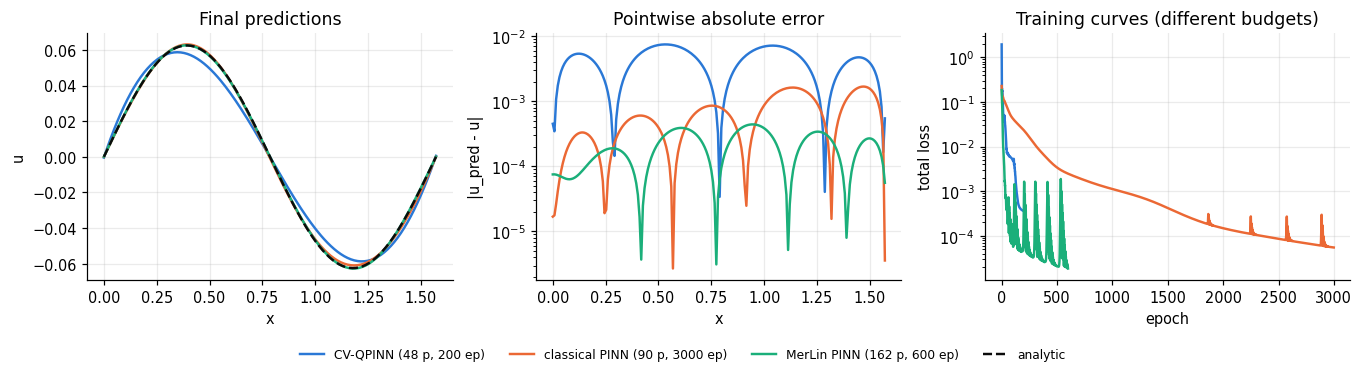

In [10]:
runs_poisson = {k: load_run(k) for k in ("poisson_qpinn_smoke_200ep", "poisson_pinn_3000ep", "poisson_merlin_600ep")}
style = {
    "poisson_qpinn_smoke_200ep": ("CV-QPINN (48 p, 200 ep)", C["qpinn"]),
    "poisson_pinn_3000ep": ("classical PINN (90 p, 3000 ep)", C["pinn"]),
    "poisson_merlin_600ep": ("MerLin PINN (162 p, 600 ep)", C["merlin"]),
}

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
for label, run in runs_poisson.items():
    name, col = style[label]
    xp = np.array(run["predictions"]["x"])
    up = np.array(run["predictions"]["u_pred"])
    ur = np.array(run["predictions"]["u_ref"])
    axes[0].plot(xp, up, color=col, label=name)
    axes[1].semilogy(xp, np.abs(up - ur) + 1e-12, color=col, label=name)
    h = history_arrays(run)
    axes[2].semilogy(h["epoch"], h["total"], color=col, label=name)
axes[0].plot(xp, ur, color=C["ref"], ls="--", label="analytic")
axes[0].set(xlabel="x", ylabel="u", title="Final predictions")
axes[1].set(xlabel="x", ylabel="|u_pred - u|", title="Pointwise absolute error")
axes[2].set(xlabel="epoch", ylabel="total loss", title="Training curves (different budgets)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=(0, 0.07, 1, 1))

rows = [["paper QPINN (4+4 layers, cutoff 10)", "CV-QPINN", 88, 5000, "1.09e-04", "—", "—", "—"]]
for label, run in runs_poisson.items():
    m = run["metrics"]
    rows.append([label, style[label][0].split(" (")[0], run["n_params"], run["training"]["epochs"],
                 fmt(m["rmse"]), fmt(m["mae"]), fmt(m["l_inf"]), f"{run['wall_time_sec']:.0f}"])
md_table(["Run", "Model", "Params", "Epochs", "RMSE", "MAE", "L∞", "Wall (s)"], rows)

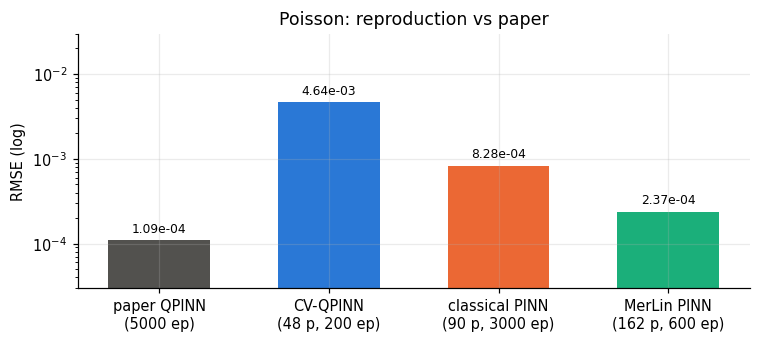

In [11]:
names = ["paper QPINN\n(5000 ep)"] + [style[k][0].replace(" (", "\n(") for k in runs_poisson]
vals = [1.09e-4] + [runs_poisson[k]["metrics"]["rmse"] for k in runs_poisson]
cols = [C["paper"]] + [style[k][1] for k in runs_poisson]
fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.bar(names, vals, color=cols, width=0.6)
ax.set_yscale("log")
ax.set(ylabel="RMSE (log)", title="Poisson: reproduction vs paper")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.25, fmt(v), ha="center", fontsize=8)
ax.set_ylim(3e-5, 3e-2)
fig.tight_layout()

*What this says.* In the smoke regime the CV-QPINN lands ~40× above the paper's number,
which is expected: it is trained for 25× fewer epochs at a lower cutoff and half the
depth. The parameter-matched classical PINN reaches a lower error than the smoke QPINN
after a longer (but much cheaper) training, and the MerLin adaptation gets within a
factor of two of the paper's RMSE in 600 epochs. Section 7 shows that{a} good part of the
QPINN's gap is not the model but the consistency loss itself.

## 7. Ablation: nested autograd vs consistency loss

The paper motivates the consistency loss by the memory cost of nested autograd, but does
not report what the trick costs in *accuracy*. This reproduction trained the same
$2+2$ smoke network for 200 epochs with both losses at cutoff 8 and 12 (records
`poisson_nested_cutoff*` and `poisson_cons_cutoff12`, plus the smoke run as the
cutoff-8 consistency case).

| Cutoff | Loss | RMSE | Wall (s) |
|---|---|---|---|
| 8 | consistency | 4.64e-03 | 168 |
| 8 | nested | 4.24e-05 | 86 |
| 12 | consistency | 1.85e-03 | 115 |
| 12 | nested | 1.51e-04 | 141 |

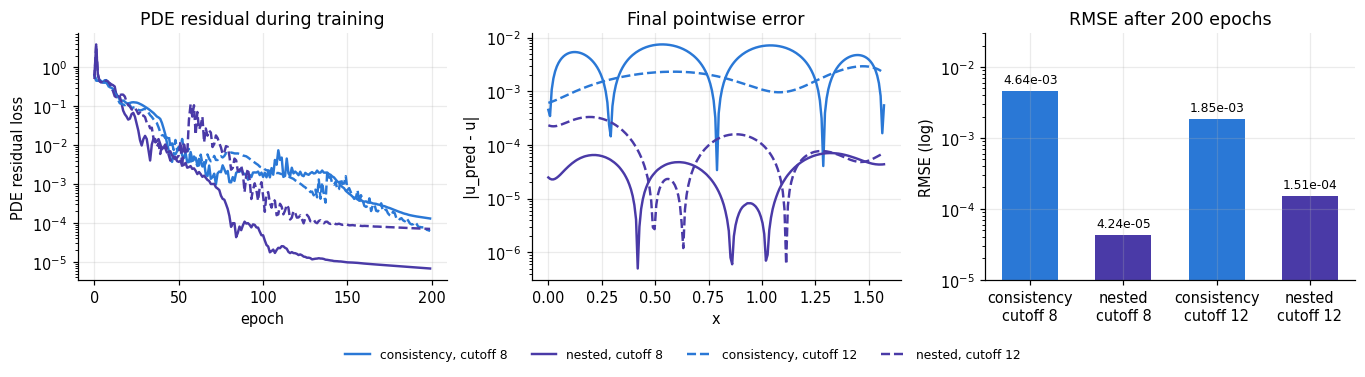

In [12]:
ablation = {
    (8, "consistency"): load_run("poisson_qpinn_smoke_200ep"),
    (8, "nested"): load_run("poisson_nested_cutoff8_200ep"),
    (12, "consistency"): load_run("poisson_cons_cutoff12_200ep"),
    (12, "nested"): load_run("poisson_nested_cutoff12_200ep"),
}
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
for (cut, loss), run in ablation.items():
    col = C["qpinn"] if loss == "consistency" else C["nested"]
    ls = "-" if cut == 8 else "--"
    name = f"{loss}, cutoff {cut}"
    h = history_arrays(run)
    axes[0].semilogy(h["epoch"], h["pde"], color=col, ls=ls, label=name)
    xp = np.array(run["predictions"]["x"])
    err = np.abs(np.array(run["predictions"]["u_pred"]) - np.array(run["predictions"]["u_ref"]))
    axes[1].semilogy(xp, err + 1e-12, color=col, ls=ls, label=name)
axes[0].set(xlabel="epoch", ylabel="PDE residual loss", title="PDE residual during training")
axes[1].set(xlabel="x", ylabel="|u_pred - u|", title="Final pointwise error")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.01))

ax = axes[2]
labels = [f"{loss}\ncutoff {cut}" for (cut, loss) in ablation]
vals = [run["metrics"]["rmse"] for run in ablation.values()]
cols = [C["qpinn"] if loss == "consistency" else C["nested"] for (_, loss) in ablation]
bars = ax.bar(labels, vals, color=cols, width=0.6)
ax.set_yscale("log")
ax.set_ylim(1e-5, 3e-2)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.3, fmt(v), ha="center", fontsize=8)
ax.set(ylabel="RMSE (log)", title="RMSE after 200 epochs")
fig.tight_layout(rect=(0, 0.07, 1, 1))

rows = [[cut, loss, fmt(run["metrics"]["rmse"]), f"{run['wall_time_sec']:.0f}"] for (cut, loss), run in ablation.items()]
md_table(["Cutoff", "Loss", "RMSE", "Wall (s)"], rows)

The memory side, measured separately with `utils/measure_nested_overhead.py`
(5 optimisation steps each; full write-up in `results/nested_vs_consistency_benchmark.md`):

| Cutoff | Peak RSS increase, nested vs consistency | Step time ratio, nested / consistency |
|---:|---:|---:|
| 8 | +1 MB | ≈ 0.9 |
| 10 | +2 MB | ≈ 1.4 |
| 12 | **+30 MB** | ≈ 1.3 |

*Verdict.* Both claims hold at once. Nested autograd does allocate super-linearly with
the cutoff (the 15× jump between cutoff 10 and 12 is the wall the paper describes, and
at the paper's cutoff 20 it would dominate). But wherever the memory is affordable,
nested autograd reaches a **12–100× lower RMSE for the same number of epochs**: the
consistency term has to *learn* the derivative, whereas autograd computes it exactly
from the start. The consistency loss is best understood as a memory optimisation with
an accuracy price, not as a free improvement.

## 8. The heat equation

Everything carries over with two changes. The input is two-dimensional, so $x$ is
displaced onto qumode 0 and $t$ onto qumode 1, and the loss gains an initial-condition
term. The paper first **pre-trains on the initial condition alone** (the network
learns the Gaussian at $t=0$), then switches on the full loss:

$$
\mathcal L = 0.1\,\mathcal L_{\rm pde} + 0.6\,\mathcal L_{\rm ic} + 0.1\,\mathcal L_{\rm bc}
 + 0.1\,\mathcal L_{\rm cons} + 0.1\,\mathcal L_{\rm tr},\qquad
\mathcal L_{\rm pde} = \big\langle(\partial_t u - \alpha\,\partial_x \hat{u}_x)^2\big\rangle .
$$

The collocation set is a regular $(x,t)$ grid, and the score is the RMSE against the
RK45 reference on a $41\times11$ evaluation grid.

### 8.1 Live smoke run

`configs/heat_smoke.json`: $2+2$ layers, cutoff 10, a $10\times8$ collocation grid, 32
initial-condition points, 8 boundary points per side, 60 pre-training epochs and
200 full epochs at learning rate 0.05. This is the configuration of the 5-seed sweep
below, so the live result can be compared with the stored seed-42 value.

In [13]:
LIVE_PRETRAIN_HEAT, LIVE_EPOCHS_HEAT = 60, 200

nx, nt, n_ic, n_bc = 10, 8, 32, 8
xt_coll = regular_grid_2d(nx, nt, heat.x_min, heat.x_max, heat.t_min, heat.t_max)
xt_ic = torch.stack([torch.linspace(heat.x_min, heat.x_max, n_ic), torch.zeros(n_ic)], dim=1)
T_ic = heat.initial(xt_ic[:, 0])
t_bc = torch.linspace(heat.t_min, heat.t_max, n_bc)
xt_bc = (
    torch.stack([torch.full((n_bc,), heat.x_min), t_bc], dim=1),
    torch.stack([torch.full((n_bc,), heat.x_max), t_bc], dim=1),
)
lambdas_heat = {"pde": 0.1, "ic": 0.6, "bc": 0.1, "consistency": 0.1, "trace": 0.1}

torch.manual_seed(42)
heat_cfg = QPINNConfig(n_qumodes=2, n_multi_layers=2, n_single_layers=2, cutoff=10, seed=42)
heat_live = QPINN(heat_cfg)
t0 = time.perf_counter()
out_heat = train_heat(
    heat_live, xt_coll, xt_ic, T_ic, xt_bc, loss_fn=heat_total_loss, lr=0.05,
    pretrain_epochs=LIVE_PRETRAIN_HEAT, epochs=LIVE_EPOCHS_HEAT, lambdas=lambdas_heat,
    alpha=heat.alpha, log_every=50,
)
wall_heat = time.perf_counter() - t0

ref_grid = heat.reference_solution(nx=41, nt=11)
xx, tt = torch.meshgrid(torch.tensor(ref_grid["x"]), torch.tensor(ref_grid["t"]), indexing="xy")
eval_xt = torch.stack([xx.flatten(), tt.flatten()], dim=1)
with torch.no_grad():
    T_live, _, _ = heat_live(eval_xt)
T_live = T_live.reshape(11, 41)
T_ref = torch.tensor(ref_grid["T"])
m_heat_live = summarise(T_live, T_ref)
sweep = json.loads((RESULTS / "seed_aggregate.json").read_text())
qpinn_group = next(g for g in sweep["groups"] if g["experiment"] == "heat_qpinn" and g["epochs"] == 200)
stored_seed42 = qpinn_group["rmse"]["values"][qpinn_group["seeds"].index(42)]
print(f"\nlive run : RMSE {m_heat_live['rmse']:.3e} in {wall_heat:.0f} s")
print(f"stored   : RMSE {stored_seed42:.3e} (5-seed sweep, seed 42)")

  [pre      0] ic=1.8476e+00


  [pre     50] ic=1.6677e-03


  [full     0] total=4.4942e-02 pde=2.8241e-01 ic=1.2139e-03 bc=8.8022e-02


  [full    50] total=3.1237e-03 pde=1.1257e-02 ic=2.1392e-03 bc=4.4736e-04


  [full   100] total=1.5165e-03 pde=2.4813e-03 ic=1.5630e-03 bc=2.2781e-04


  [full   150] total=1.2188e-03 pde=1.2967e-03 ic=9.4325e-04 bc=9.3592e-04


  [full   199] total=6.9805e-04 pde=4.8220e-04 ic=6.3384e-04 bc=2.0560e-04

live run : RMSE 1.030e-02 in 77 s
stored   : RMSE 1.030e-02 (5-seed sweep, seed 42)


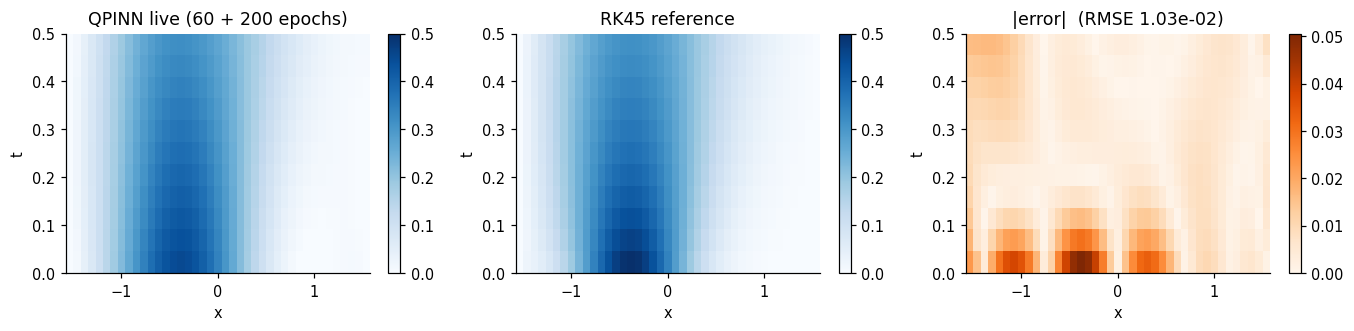

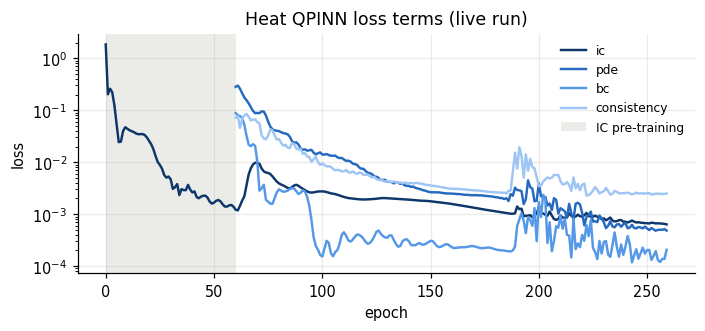

In [14]:
def plot_heat_grids(T_pred, T_ref, x, t, title, rmse):
    err = np.abs(np.asarray(T_pred) - np.asarray(T_ref))
    extent = (float(np.min(x)), float(np.max(x)), float(np.min(t)), float(np.max(t)))
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.1))
    for ax, data, name, cmap, vmax in zip(
        axes, (T_pred, T_ref, err), (title, "RK45 reference", f"|error|  (RMSE {rmse:.2e})"),
        ("Blues", "Blues", "Oranges"), (0.5, 0.5, None),
    ):
        im = ax.imshow(np.asarray(data), origin="lower", aspect="auto", cmap=cmap, extent=extent, vmin=0, vmax=vmax)
        ax.grid(False)
        ax.set(xlabel="x", ylabel="t", title=name)
        fig.colorbar(im, ax=ax)
    fig.tight_layout()


plot_heat_grids(T_live, T_ref, ref_grid["x"], ref_grid["t"], "QPINN live (60 + 200 epochs)", m_heat_live["rmse"])

hh = out_heat["history"]
ep = np.array([h["epoch"] for h in hh])
fig, ax = plt.subplots(figsize=(6.5, 3.1))
for k, col in zip(("ic", "pde", "bc", "consistency"), (BLUES[3], BLUES[2], BLUES[1], BLUES[0])):
    ax.semilogy(ep, [h.get(k, np.nan) for h in hh], color=col, label=k)
ax.axvspan(0, LIVE_PRETRAIN_HEAT, color="#d9d8d3", alpha=0.5, lw=0, label="IC pre-training")
ax.set(xlabel="epoch", ylabel="loss", title="Heat QPINN loss terms (live run)")
ax.legend(fontsize=8)
fig.tight_layout()

The largest errors sit at early times near the peak of the Gaussian, where the solution
has the sharpest curvature, and at the boundaries. This is the same pattern as Figure 11
of the paper.

### 8.2 Curated single runs and the 5-seed sweep

Two curated runs are stored with their full history: the smoke QPINN trained a little
longer (60 + 250 epochs, `heat_qpinn_smoke_250ep`) and the parameter-matched classical
PINN (`heat_pinn_1000ep`: 2 inputs, one hidden layer of 8, 42 parameters, 300 + 1000
epochs at learning rate 0.01, same loss and same pre-training). Both used seed 42.

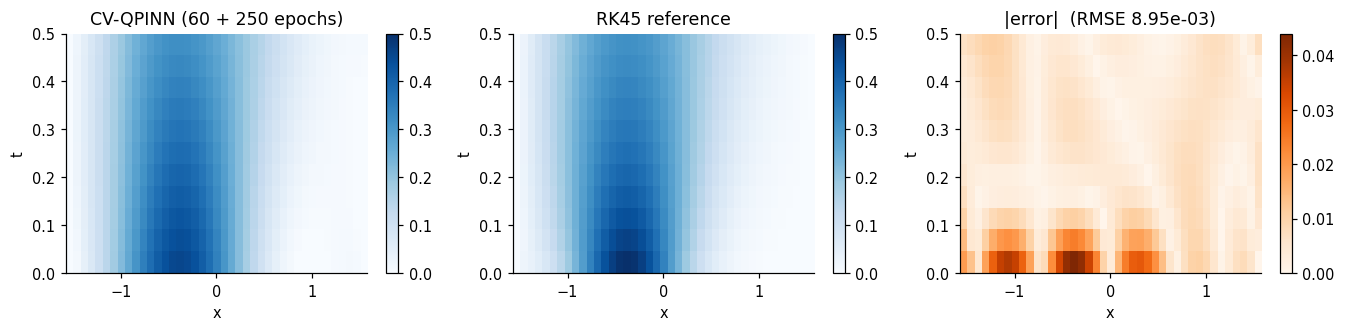

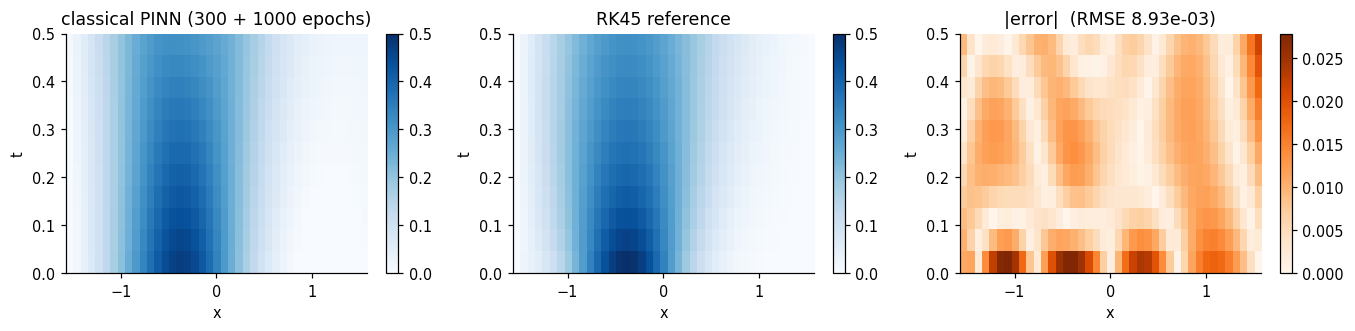

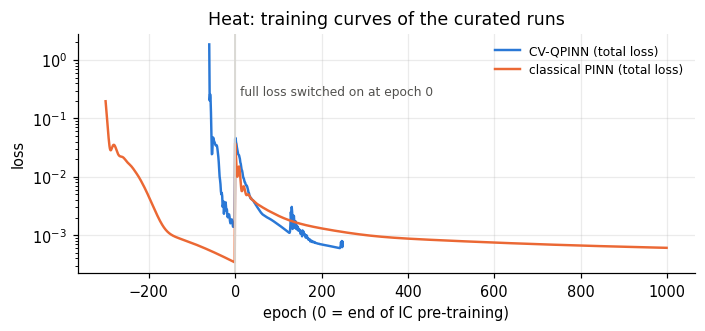

In [15]:
for label, title in (("heat_qpinn_smoke_250ep", "CV-QPINN (60 + 250 epochs)"), ("heat_pinn_1000ep", "classical PINN (300 + 1000 epochs)")):
    run = load_run(label)
    p = run["predictions"]
    plot_heat_grids(p["u_pred"], p["u_ref"], p["x"], p["t"], title, run["metrics"]["rmse"])

fig, ax = plt.subplots(figsize=(6.5, 3.1))
for label, col, name in (("heat_qpinn_smoke_250ep", C["qpinn"], "CV-QPINN"), ("heat_pinn_1000ep", C["pinn"], "classical PINN")):
    run = load_run(label)
    h = history_arrays(run)
    pre = run["training"]["pretrain_epochs"]
    ax.semilogy(h["epoch"] - pre, h["total"], color=col, label=f"{name} (total loss)")
ax.axvline(0, color="#d9d8d3", lw=1.2)
ax.text(12, 0.25, "full loss switched on at epoch 0", fontsize=8, color=C["paper"])
ax.set(xlabel="epoch (0 = end of IC pre-training)", ylabel="loss", title="Heat: training curves of the curated runs")
ax.legend(fontsize=8)
fig.tight_layout()

A single seed is not enough to compare two architectures, so both were re-run with 5
seeds under the smoke budget (`results/seed_aggregate.json`, write-up in
`results/heat_seed_sweep.md`). The paper's Table IV reports RMSE $1.24\times10^{-2}$ for the
QPINN and $2.09\times10^{-2}$ for its classical PINN of the same size, and reads this as a
slight quantum advantage.

| Model | Params | Seeds | RMSE mean ± std | MAE | L∞ | Paper RMSE |
|---|---|---|---|---|---|---|
| CV-QPINN | 48 | 5 | 1.23e-02 ± 4.8e-03 | 8.59e-03 | 5.49e-02 | 1.24e-02 |
| classical PINN | 42 | 5 | 8.74e-03 ± 1.2e-03 | 7.03e-03 | 3.04e-02 | 2.09e-02 |

QPINN / PINN mean RMSE ratio: 1.40   (paper: 0.59)


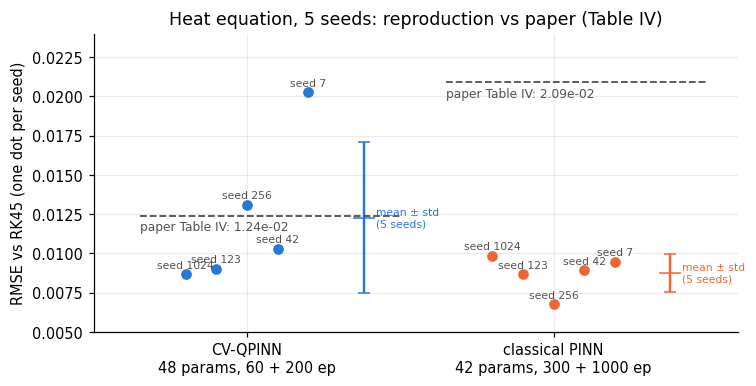

In [16]:
groups = {
    "qpinn": next(g for g in sweep["groups"] if g["experiment"] == "heat_qpinn" and g["epochs"] == 200),
    "pinn": next(g for g in sweep["groups"] if g["experiment"] == "heat_pinn"),
}
paper = {"qpinn": 1.24e-2, "pinn": 2.09e-2}
names = {"qpinn": "CV-QPINN\n48 params, 60 + 200 ep", "pinn": "classical PINN\n42 params, 300 + 1000 ep"}

fig, ax = plt.subplots(figsize=(7, 3.6))
for i, key in enumerate(("qpinn", "pinn")):
    g = groups[key]
    vals = np.array(g["rmse"]["values"])
    jitter = np.linspace(-0.2, 0.2, len(vals))
    ax.scatter(i + jitter, vals, color=C[key], s=36, zorder=3)
    for j, s in zip(jitter, g["seeds"]):
        ax.text(i + j, vals[g["seeds"].index(s)] + 4e-4, f"seed {s}", ha="center", fontsize=7, color=C["paper"])
    ax.errorbar(i + 0.38, g["rmse"]["mean"], yerr=g["rmse"]["std"], fmt="_", color=C[key], ms=14, capsize=4, lw=1.6)
    ax.text(i + 0.42, g["rmse"]["mean"], "mean ± std\n(5 seeds)", va="center", fontsize=7, color=C[key])
    ax.hlines(paper[key], i - 0.35, i + 0.5, color=C["paper"], ls="--", lw=1.2)
    ax.text(i - 0.35, paper[key] - 3e-4, f"paper Table IV: {paper[key]:.2e}", va="top", fontsize=8, color=C["paper"])
ax.set_xticks([0, 1])
ax.set_xticklabels([names["qpinn"], names["pinn"]])
ax.set_xlim(-0.5, 1.6)
ax.set_ylim(5e-3, 2.4e-2)
ax.set(ylabel="RMSE vs RK45 (one dot per seed)", title="Heat equation, 5 seeds: reproduction vs paper (Table IV)")
fig.tight_layout()

rows = []
for key in ("qpinn", "pinn"):
    g = groups[key]
    rows.append([names[key].splitlines()[0], g["n_params"], len(g["seeds"]),
                 f"{g['rmse']['mean']:.2e} ± {g['rmse']['std']:.1e}",
                 f"{g['mae']['mean']:.2e}", f"{g['l_inf']['mean']:.2e}", f"{paper[key]:.2e}"])
md_table(["Model", "Params", "Seeds", "RMSE mean ± std", "MAE", "L∞", "Paper RMSE"], rows)
ratio = groups["qpinn"]["rmse"]["mean"] / groups["pinn"]["rmse"]["mean"]
print(f"QPINN / PINN mean RMSE ratio: {ratio:.2f}   (paper: {paper['qpinn'] / paper['pinn']:.2f})")

*Reading the sweep.*

* The QPINN number **reproduces**: our 5-seed mean sits on top of the paper's
  $1.24\times10^{-2}$, with the smoke budget (cutoff 10 instead of 20, 260 instead of
  1300 epochs).
* The classical baseline does **not**: trained with the same consistency loss, the same
  pre-training and matched parameters, the classical PINN is 2.4× better than the paper's
  classical number, beats the QPINN on average by 1.4×, and is about 4× more stable across
  seeds. The most likely explanation is that the paper's classical PINN was trained
  without the consistency-loss and pre-training machinery that its QPINN received.
* Under a matched-effort comparison the "slight quantum advantage" of Table IV is
  therefore not supported. The QPINN remains a working solver, but it is not the better one
  here.

## 9. MerLin photonic adaptation

MerLin simulates *linear-optical* photonic circuits: single photons sent through a
programmable interferometer and counted at the output. Squeezing, displacement and the
Kerr non-linearity, i.e. everything that makes the paper's CV network expressive, are not
native operations there. A literal port is therefore not meaningful, and this
reproduction does **not** claim one.

What does transfer is the training scheme. `lib/merlin_pinn.py` builds a MerLin
`QuantumLayer` with 6 modes and 3 photons (one photon in every other mode), encodes $x$
as rotation angles on three modes, applies trainable entangling layers, and reads the
probabilities of the 20 unbunched output patterns. Two trainable linear heads map those
probabilities to $(u,\hat{u}_x)$, and from there on the model is trained with exactly the
Poisson loss of section 4. The trace output is a constant 1 (probabilities always sum
to one), so the trace weight is set to 0.

input Fock state      : [1, 0, 1, 0, 1, 0]
measured output patterns: 20 (unbunched, 3 photons in 6 modes)
trainable parameters  : 162 (interferometer 120, two linear heads 42)
  [epoch     0] total=1.8353e-01 pde=5.0281e-01 bc=1.6960e-03 consist=3.7482e-02 trace=0.0000e+00


  [epoch    50] total=3.3417e-04 pde=2.4449e-04 bc=1.0289e-05 consist=7.7359e-04 trace=0.0000e+00


  [epoch   100] total=8.1639e-05 pde=2.1369e-04 bc=1.8669e-06 consist=2.6092e-05 trace=0.0000e+00


  [epoch   149] total=9.2551e-05 pde=2.5516e-04 bc=2.3637e-06 consist=1.5597e-05 trace=0.0000e+00

live (150 ep): RMSE 5.857e-04 in 17 s
stored (600 ep): RMSE 2.373e-04


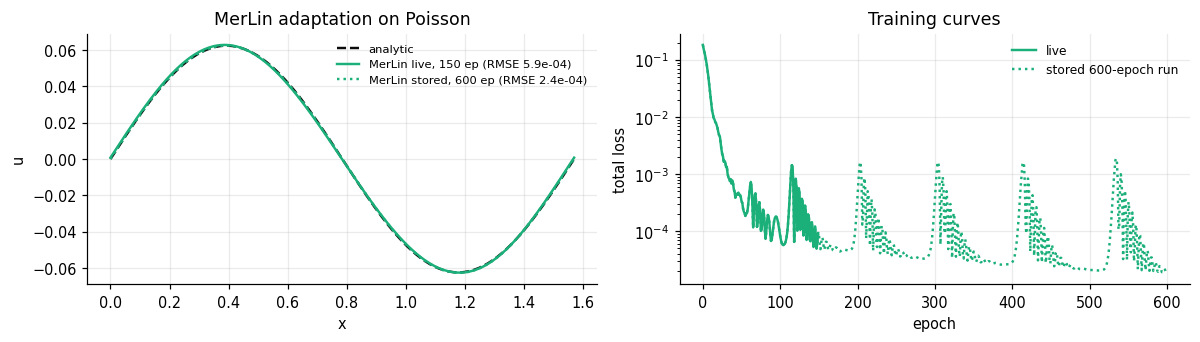

In [17]:
from lib.merlin_pinn import MerLinPINN

LIVE_EPOCHS_MERLIN = 150  # the curated record used 600

torch.manual_seed(42)
merlin_live = MerLinPINN(n_modes=6, input_modes=(0, 1, 2), entangling_layers=3, n_photons=3, scale=math.pi / 2)
print("input Fock state      :", list(merlin_live.qlayer.input_state))
print("measured output patterns:", merlin_live.qlayer.output_size, "(unbunched, 3 photons in 6 modes)")
print("trainable parameters  :", merlin_live.n_trainable(),
      f"(interferometer {merlin_live.n_trainable() - 2 * (merlin_live.qlayer.output_size + 1)}, two linear heads {2 * (merlin_live.qlayer.output_size + 1)})")

lambdas_merlin = {"pde": 0.34, "bc": 0.34, "consistency": 0.32, "trace": 0.0}
t0 = time.perf_counter()
out_merlin = train_poisson(
    merlin_live, x_coll, x_bc, loss_fn=poisson_total_loss, lr=0.02,
    epochs=LIVE_EPOCHS_MERLIN, lambdas=lambdas_merlin, log_every=50,
)
wall_merlin = time.perf_counter() - t0
with torch.no_grad():
    u_merlin, _, _ = merlin_live(x_eval)
m_merlin = summarise(u_merlin, u_ref)
stored_merlin = load_run("poisson_merlin_600ep")
print(f"\nlive ({LIVE_EPOCHS_MERLIN} ep): RMSE {m_merlin['rmse']:.3e} in {wall_merlin:.0f} s")
print(f"stored (600 ep): RMSE {stored_merlin['metrics']['rmse']:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
ax = axes[0]
ax.plot(x_eval, u_ref, color=C["ref"], ls="--", label="analytic")
ax.plot(x_eval, u_merlin, color=C["merlin"], label=f"MerLin live, {LIVE_EPOCHS_MERLIN} ep (RMSE {m_merlin['rmse']:.1e})")
ax.plot(stored_merlin["predictions"]["x"], stored_merlin["predictions"]["u_pred"], color=C["merlin"], ls=":",
        label=f"MerLin stored, 600 ep (RMSE {stored_merlin['metrics']['rmse']:.1e})")
ax.set(xlabel="x", ylabel="u", title="MerLin adaptation on Poisson")
ax.legend(fontsize=7.5)
ax = axes[1]
h_live = np.array([h["total"] for h in out_merlin["history"]])
h_stored = history_arrays(stored_merlin)
ax.semilogy(np.arange(len(h_live)), h_live, color=C["merlin"], label="live")
ax.semilogy(h_stored["epoch"], h_stored["total"], color=C["merlin"], ls=":", label="stored 600-epoch run")
ax.set(xlabel="epoch", ylabel="total loss", title="Training curves")
ax.legend(fontsize=8)
fig.tight_layout()

The linear-optics network learns the Poisson solution quickly and, with 600 epochs,
reaches an RMSE within a factor of two of the paper's CV result. It should be read as
evidence that the consistency-loss scheme is architecture-agnostic, not as a photonic
reproduction of the CV circuit: it has three times the parameters, a different encoding
and a different (classical) read-out head.

## 10. Conclusions

**What reproduces**

* The CV-QPINN itself. The consistency-loss machinery trains as described, and on the
  heat equation the 5-seed smoke reproduction lands on the paper's QPINN RMSE
  ($1.23\times10^{-2}$ vs $1.24\times10^{-2}$).
* The memory argument for the consistency loss. Nested autograd through the CV
  simulator allocates super-linearly with the Fock cutoff (a 15× jump between cutoff
  10 and 12).

**What does not**

* The comparison with the classical PINN. With the same loss, the same pre-training and
  a matched parameter count, the classical network beats the QPINN on the heat equation
  by 1.4× on average and is 4× more stable across seeds. The paper's classical number
  ($2.09\times10^{-2}$) is 2.4× worse than what{a} fair baseline achieves.
* The framing of the consistency loss as a pure improvement. At cutoffs where memory is
  not the bottleneck, nested autograd is 12–100× more accurate for the same epochs.

**Limitations of this walkthrough**

* All numbers are from *smoke* configurations (cutoff 8–10, 2+2 layers, hundreds of
  epochs). The paper-accurate configurations `configs/poisson_original.json` (cutoff 10,
  4+4 layers, 5000 epochs) and `configs/heat_original.json` (cutoff 20, 1000 epochs) are
  provided but take hours on CPU.
* The paper's X8 optical-loss study (§V) is implemented at the gate level
  (`lib/cv_simulator.py::expectation_x_with_loss`) but was not run.
* The MerLin model is a different photonic architecture, not a CV port.

**Going further**

```bash
# from the repository root
python implementation.py --paper CV_QPINN_PDE --config configs/poisson_original.json
python implementation.py --paper CV_QPINN_PDE --config configs/heat_original.json
python implementation.py --paper CV_QPINN_PDE --config configs/poisson_qpinn_nested.json --cutoff 12

# promote a finished run so this notebook can plot it
python utils/curate_results.py outdir/run_<STAMP> --label <label> --with-arrays --plot
```

Any record written with `--with-arrays` can be loaded here with `load_run("<label>")`
and dropped into the plotting cells above.